# Document Category EDA

Exploratory analysis of `doc_category` (16 broad categories). Examines distributions,
time series trends, relationships with redaction metrics, and document length patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PALETTE = "Set2"
DEFAULT_FIGSIZE = (10, 6)
WIDE_FIGSIZE = (14, 5)
HIST_KWARGS = dict(bins=30, edgecolor="black", alpha=0.7)

In [2]:
DOC_PATH = "../data/document_level.csv"
LOOKUP_PATH = "../data/lookup_table.csv"

doc_df = pd.read_csv(DOC_PATH)
lookup_df = pd.read_csv(LOOKUP_PATH)

df = doc_df.merge(
    lookup_df[["folder_name", "doc_category", "year"]],
    on="folder_name",
    how="left",
    suffixes=("", "_lookup"),
)
# Prefer the lookup year if present; fall back to document_level year
if "year_lookup" in df.columns:
    df["year"] = df["year_lookup"].fillna(df["year"])
    df.drop(columns=["year_lookup"], inplace=True)

print(f"document_level shape: {doc_df.shape}")
print(f"merged shape:         {df.shape}")
print(f"unique doc_category:  {df['doc_category'].nunique()}")
print()
df.head()

document_level shape: (8725, 34)
merged shape:         (8725, 35)
unique doc_category:  16



,folder_name,arbitration_id,year,doc_name,match_method,total_pages,pages_with_detections,pages_no_detections,pages_with_errors,total_detections,...,total_footer,total_high_confidence,total_medium_confidence,total_low_confidence,mean_heaviness_score,max_heaviness_score,modal_redaction_level,has_any_redaction,fraction_pages_with_redactions,doc_category
0,1987_aapl_v_sri_lanka_dissenting_opinion_of_sa...,1987_aapl_v_sri_lanka,1987,dissenting_opinion_of_samuel_k_b_asante,metadata,12,0,12,0,0,...,0,0,0,0,0.0,0,none,False,0.0,Arbitrator Opinions
1,1987_aapl_v_sri_lanka_final_award,1987_aapl_v_sri_lanka,1987,final_award,metadata,24,0,24,0,0,...,0,0,0,0,0.0,0,none,False,0.0,Awards
2,1993_amt_v_democratic_republic_of_the_congo_aw...,1993_amt_v_democratic_republic_of_the_congo,1993,award_reproduced_with_permission_from_36_ilm_1...,metadata,22,0,22,0,0,...,0,0,0,0,0.0,0,none,False,0.0,Awards
3,1993_amt_v_democratic_republic_of_the_congo_st...,1993_amt_v_democratic_republic_of_the_congo,1993,statement_of_individual_opinion_and_declaratio...,metadata,6,0,6,0,0,...,0,0,0,0,0.0,0,none,False,0.0,Arbitrator Opinions
4,1994_saar_papier_v_poland_i_decision_of_the_sw...,1994_saar_papier_v_poland_i,1994,decision_of_the_swiss_federal_tribunal_german,metadata,7,0,7,0,0,...,0,0,0,0,0.0,0,none,False,0.0,Domestic Court Proceedings


## Distribution

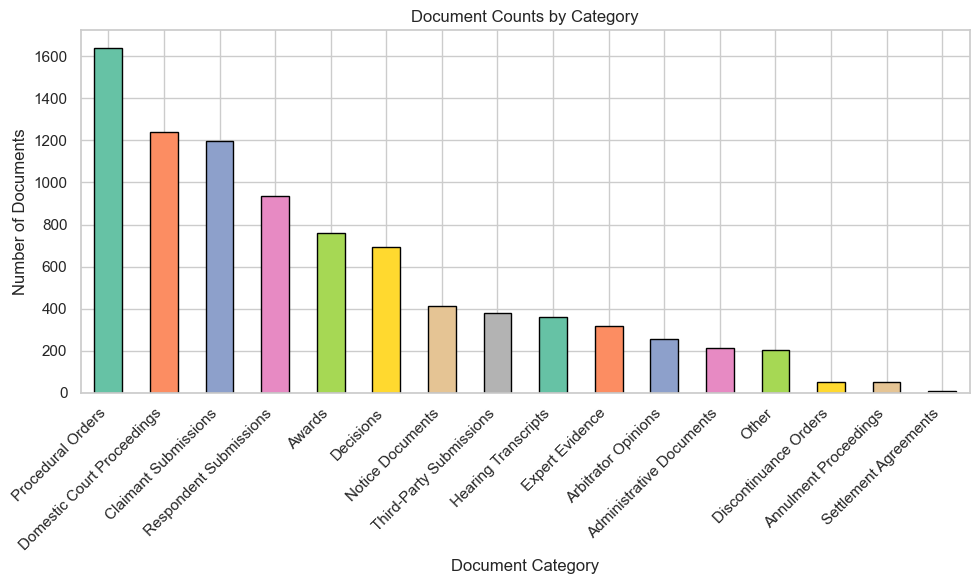

In [3]:
# Bar chart of all 16 doc_category values (sorted by count)
cat_counts = df["doc_category"].value_counts()

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
cat_counts.plot.bar(ax=ax, color=sns.color_palette(PALETTE, len(cat_counts)), edgecolor="black")
ax.set_title("Document Counts by Category")
ax.set_xlabel("Document Category")
ax.set_ylabel("Number of Documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

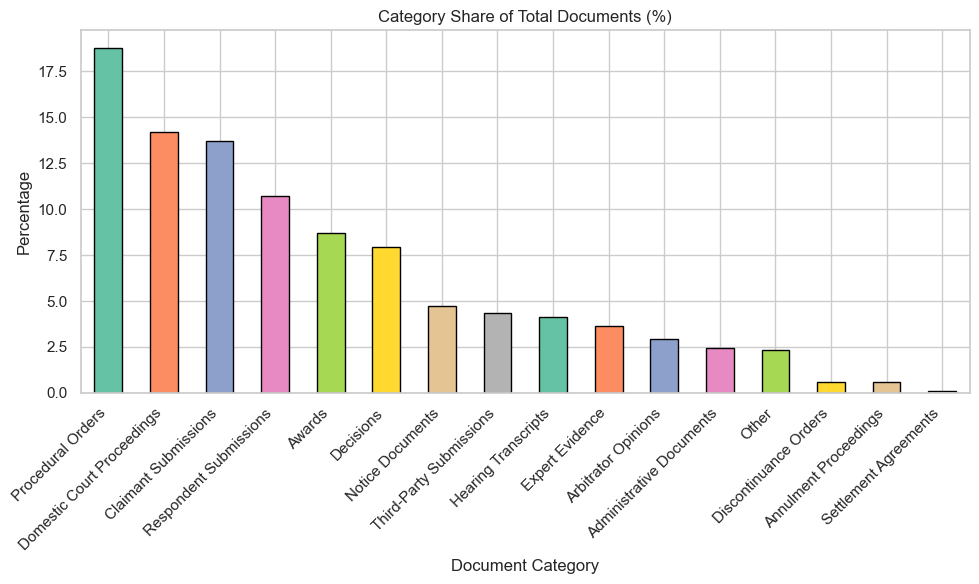

In [4]:
# Proportional bar showing share of total
cat_pct = (cat_counts / cat_counts.sum() * 100)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
cat_pct.plot.bar(ax=ax, color=sns.color_palette(PALETTE, len(cat_pct)), edgecolor="black")
ax.set_title("Category Share of Total Documents (%)")
ax.set_xlabel("Document Category")
ax.set_ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Time Series

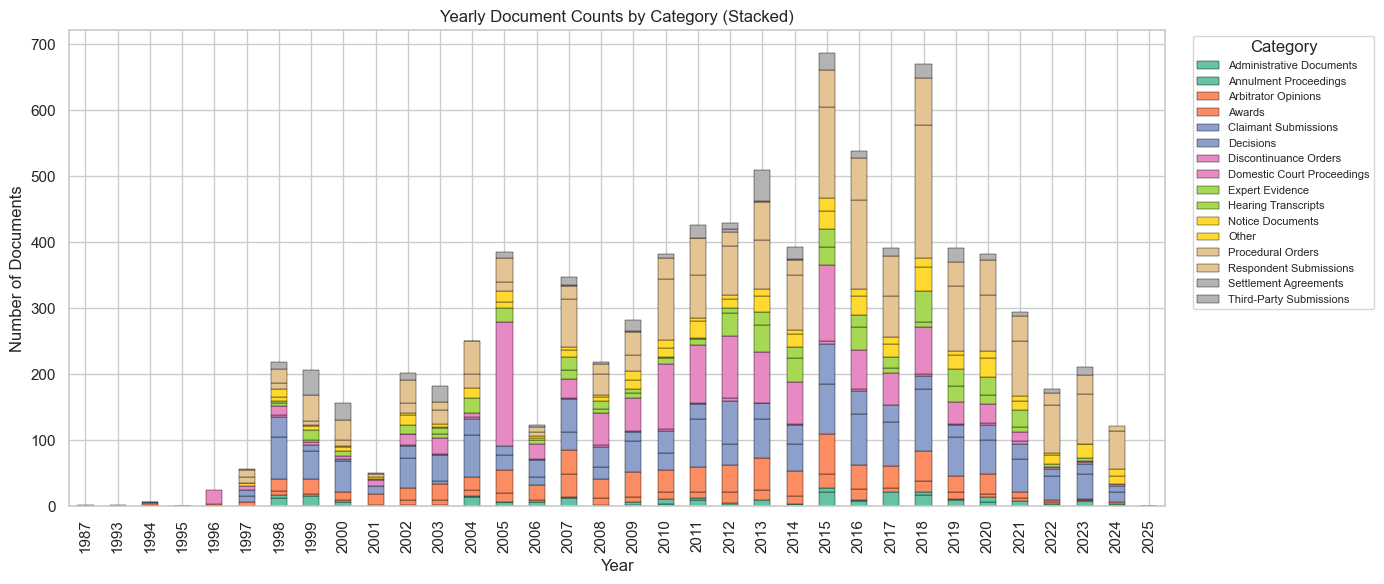

In [5]:
# Yearly document counts by category — stacked bar chart
yearly = df.groupby(["year", "doc_category"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
yearly.plot.bar(stacked=True, ax=ax, colormap="Set2", edgecolor="black", linewidth=0.3)
ax.set_title("Yearly Document Counts by Category (Stacked)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Documents")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

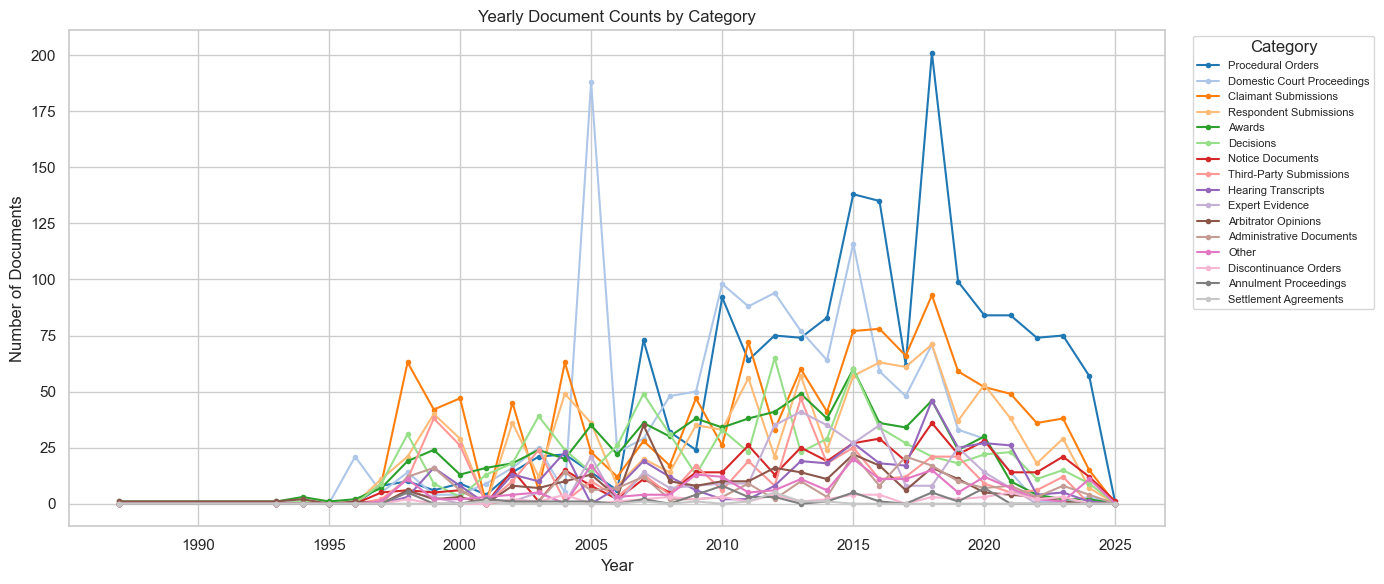

In [6]:
# Yearly document counts — line plot, one line per category
fig, ax = plt.subplots(figsize=(14, 6))
for i, cat in enumerate(cat_counts.index):
    series = yearly[cat] if cat in yearly.columns else pd.Series(dtype=float)
    ax.plot(series.index, series.values, marker="o", markersize=3,
            label=cat, color=sns.color_palette("tab20", len(cat_counts))[i])
ax.set_title("Yearly Document Counts by Category")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Documents")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

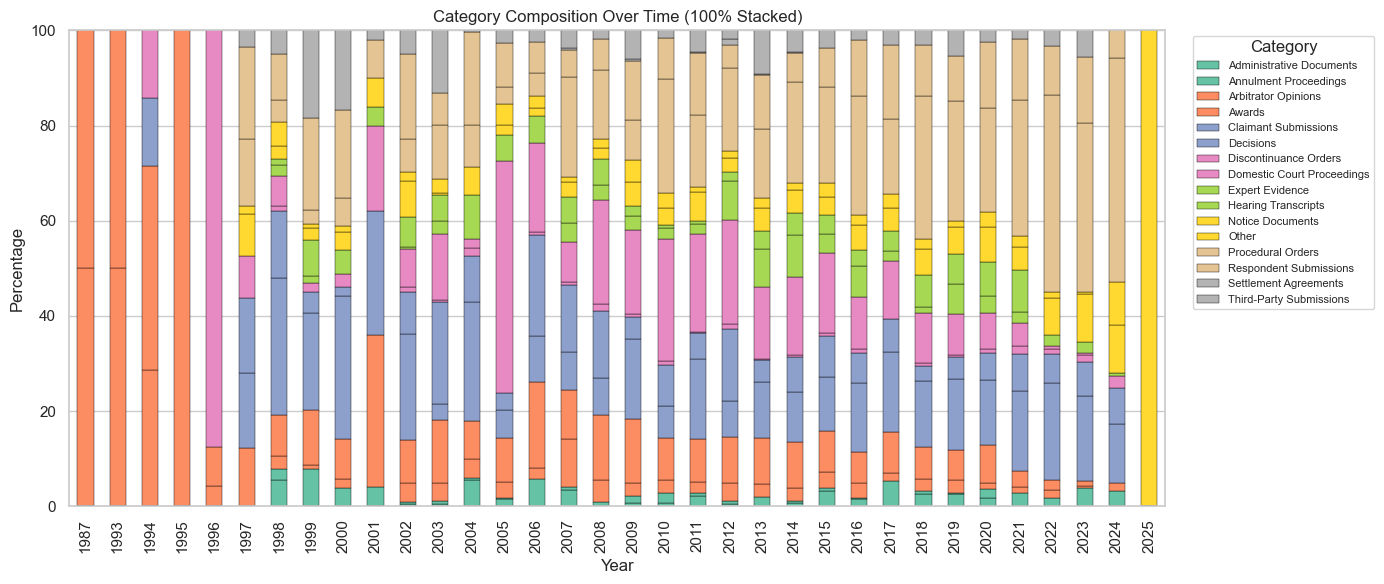

In [7]:
# 100% stacked bar — composition over time
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
yearly_pct.plot.bar(stacked=True, ax=ax, colormap="Set2", edgecolor="black", linewidth=0.3)
ax.set_title("Category Composition Over Time (100% Stacked)")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Redaction Relationship

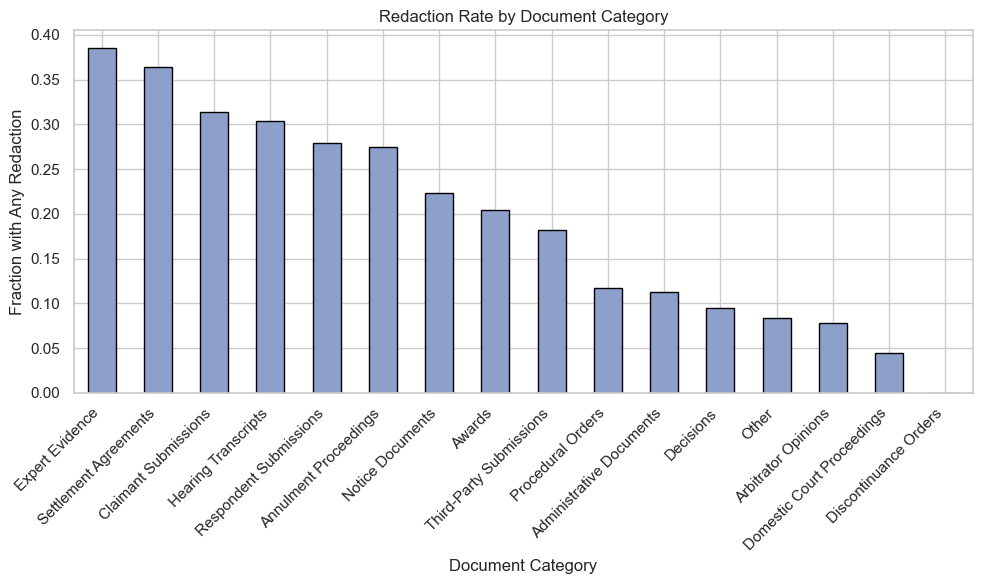

In [8]:
# Redaction rate by category (fraction of docs with any redaction)
redaction_rate = df.groupby("doc_category")["has_any_redaction"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
redaction_rate.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[2], edgecolor="black")
ax.set_title("Redaction Rate by Document Category")
ax.set_xlabel("Document Category")
ax.set_ylabel("Fraction with Any Redaction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<positron-console-cell-9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



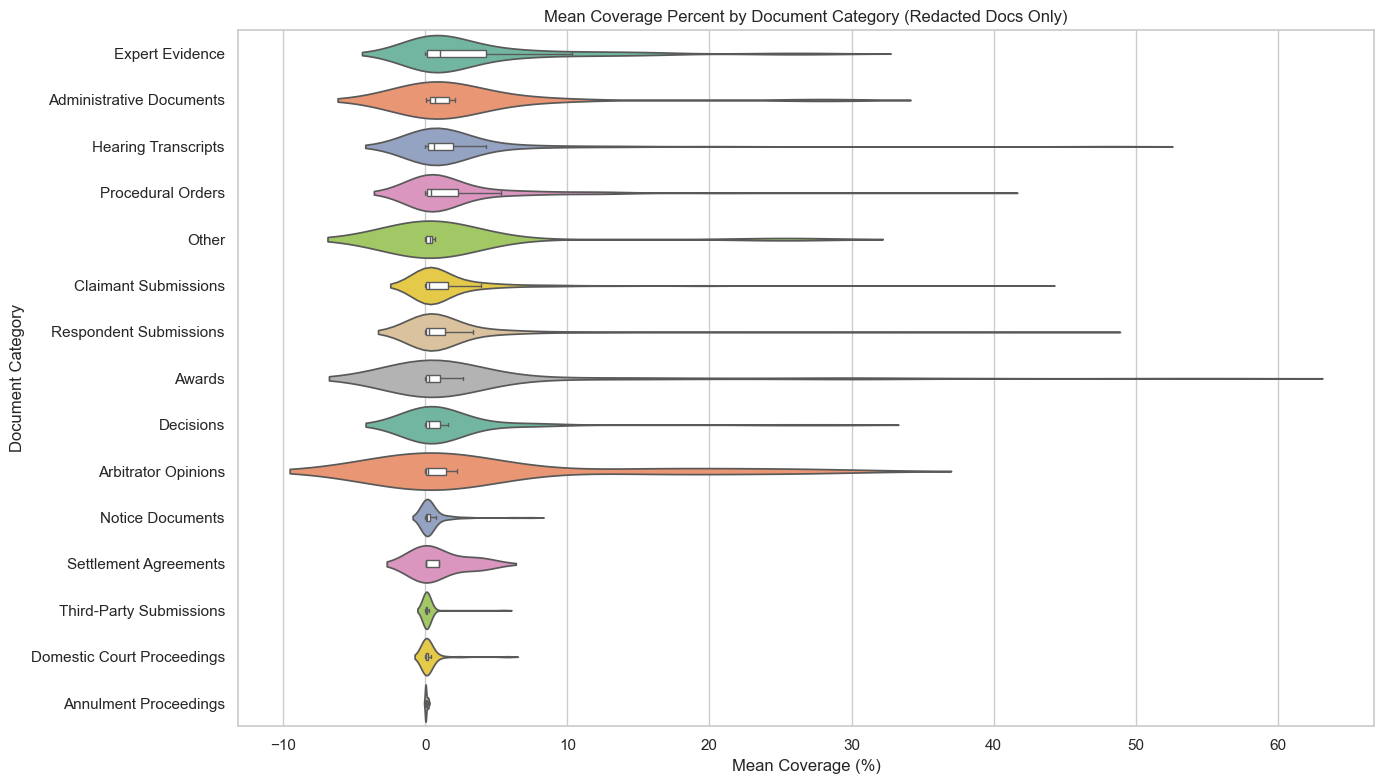

In [9]:
# Violin + box plot — mean_coverage_percent by doc_category (redacted docs only)
redacted = df[df["has_any_redaction"] == True].copy()
cat_order = redacted.groupby("doc_category")["mean_coverage_percent"].median().sort_values(ascending=False).index.tolist()
redacted["doc_category"] = pd.Categorical(redacted["doc_category"], categories=cat_order, ordered=True)

fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(data=redacted, y="doc_category", x="mean_coverage_percent",
               palette=PALETTE, inner=None, ax=ax)
sns.boxplot(data=redacted, y="doc_category", x="mean_coverage_percent",
            width=0.15, boxprops=dict(facecolor="white", zorder=2),
            ax=ax, fliersize=0)
ax.set_title("Mean Coverage Percent by Document Category (Redacted Docs Only)")
ax.set_xlabel("Mean Coverage (%)")
ax.set_ylabel("Document Category")
plt.tight_layout()
plt.show()

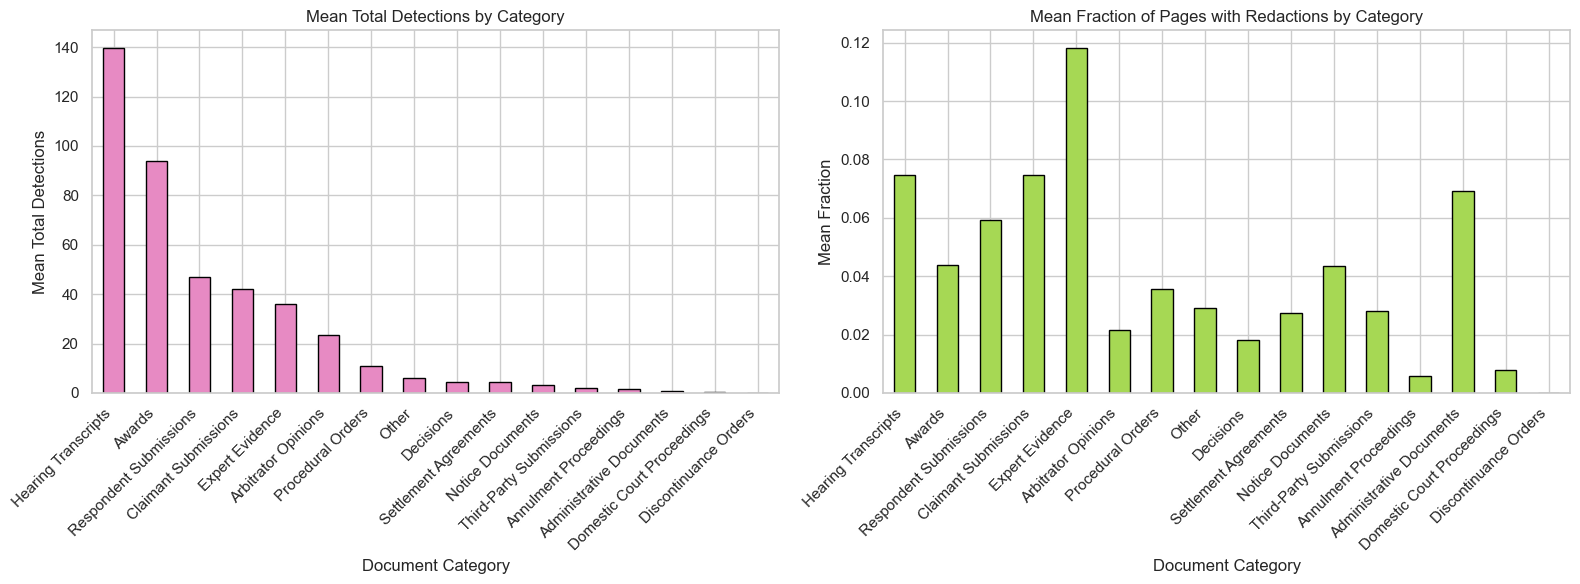

In [10]:
# Grouped bar — mean total_detections and mean fraction_pages_with_redactions by category
grouped_stats = df.groupby("doc_category").agg(
    mean_detections=("total_detections", "mean"),
    mean_frac_pages=("fraction_pages_with_redactions", "mean"),
).sort_values("mean_detections", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

grouped_stats["mean_detections"].plot.bar(
    ax=axes[0], color=sns.color_palette(PALETTE)[3], edgecolor="black"
)
axes[0].set_title("Mean Total Detections by Category")
axes[0].set_xlabel("Document Category")
axes[0].set_ylabel("Mean Total Detections")
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

grouped_stats["mean_frac_pages"].plot.bar(
    ax=axes[1], color=sns.color_palette(PALETTE)[4], edgecolor="black"
)
axes[1].set_title("Mean Fraction of Pages with Redactions by Category")
axes[1].set_xlabel("Document Category")
axes[1].set_ylabel("Mean Fraction")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

## Length Relationship

<positron-console-cell-11>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



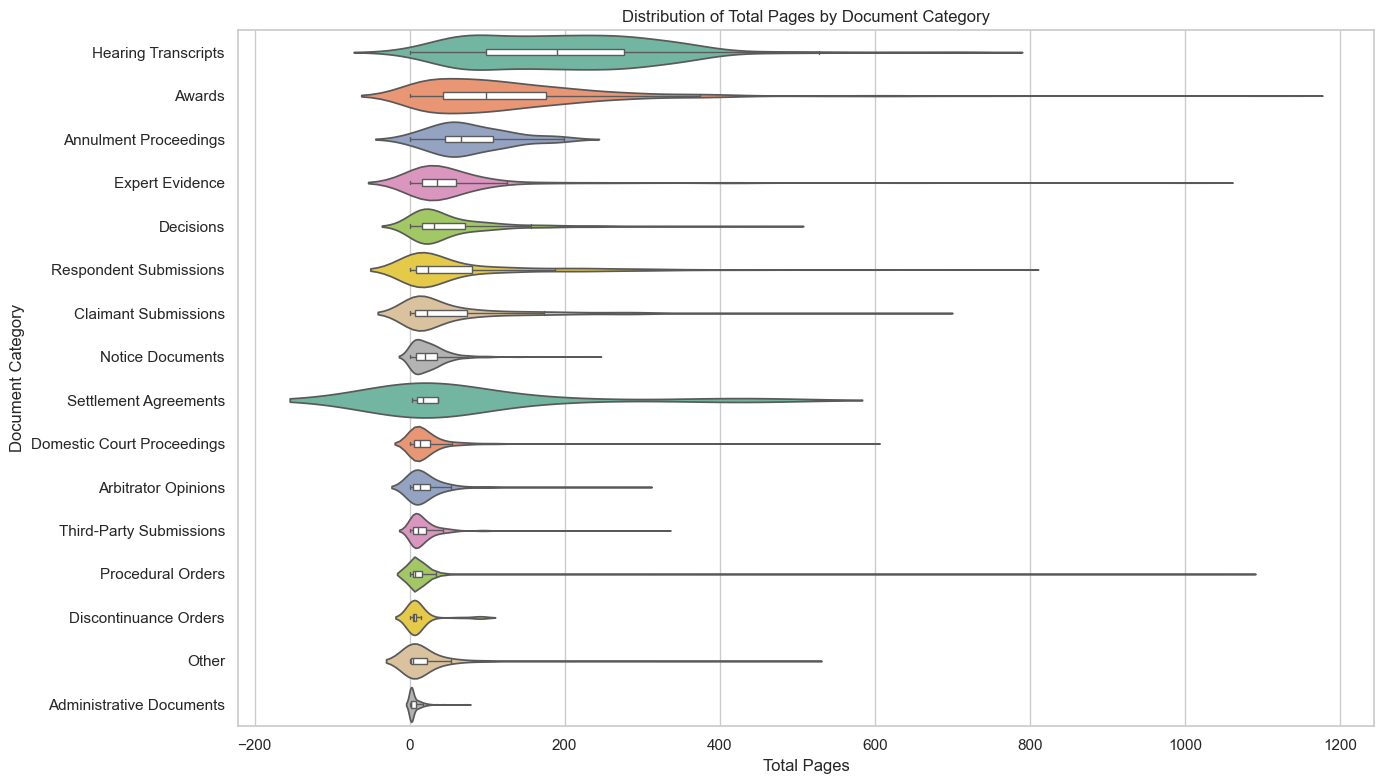

In [11]:
# Violin + box plot — total_pages by doc_category
page_order = df.groupby("doc_category")["total_pages"].median().sort_values(ascending=False).index.tolist()
plot_df = df.copy()
plot_df["doc_category"] = pd.Categorical(plot_df["doc_category"], categories=page_order, ordered=True)

fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(data=plot_df, y="doc_category", x="total_pages",
               palette=PALETTE, inner=None, ax=ax)
sns.boxplot(data=plot_df, y="doc_category", x="total_pages",
            width=0.15, boxprops=dict(facecolor="white", zorder=2),
            ax=ax, fliersize=0)
ax.set_title("Distribution of Total Pages by Document Category")
ax.set_xlabel("Total Pages")
ax.set_ylabel("Document Category")
plt.tight_layout()
plt.show()

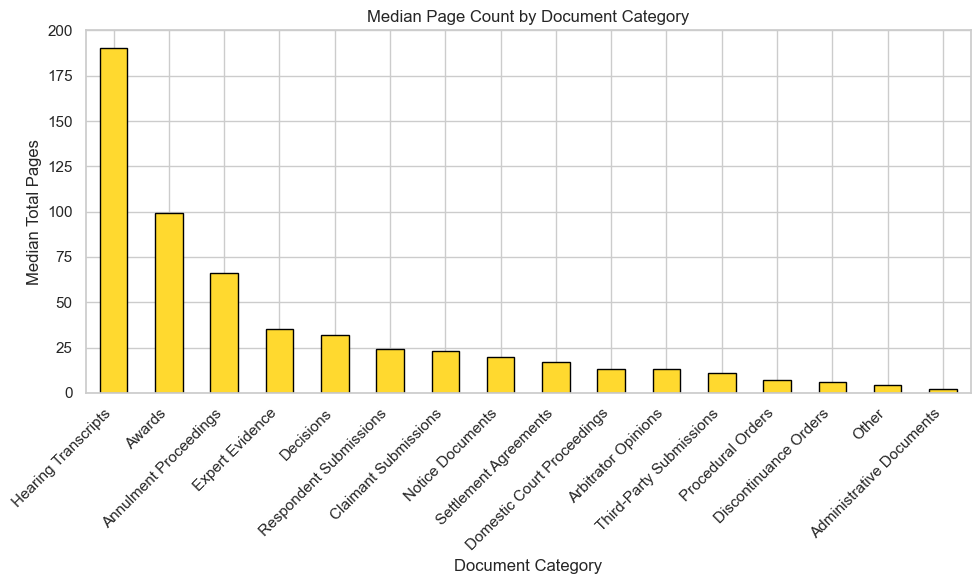

In [12]:
# Bar chart — median total_pages by doc_category
median_pages = df.groupby("doc_category")["total_pages"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
median_pages.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[5], edgecolor="black")
ax.set_title("Median Page Count by Document Category")
ax.set_xlabel("Document Category")
ax.set_ylabel("Median Total Pages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()